# Module 1: Whole-Exome Sequencing (WES) Somatic Variant Benchmarking

## What this notebook does, in plain language

A tumor is different from normal tissue because its DNA has accumulated mutations. Some
of those mutations help the cancer grow; most are just along for the ride. Finding the
real, tumor-specific mutations (called **somatic variants**, as opposed to **germline**
variants you are born with and carry in every cell) is one of the basic tasks in cancer
genomics.

**Whole-exome sequencing (WES)** reads out the DNA sequence of just the protein-coding
part of the genome, the "exome", which is about 1-2% of the full genome but contains most
of the mutations doctors currently know how to interpret. It is cheaper and faster than
sequencing the whole genome, which is why it is still widely used in the clinic today.

This notebook does not run any sequencing software itself. A Nextflow pipeline
(`pipelines/wes/main.nf`) already did that: it aligned reads, marked duplicate reads,
restricted the data to exome regions, called somatic mutations with a tool called
Mutect2, and compared the results against a published, independently verified list of
the real mutations in this exact tumor sample (a "truth set"). What this notebook does is
load those results and ask: **how good were the calls?** How many real mutations did the
pipeline find, how many did it miss, and how many "mutations" did it call that were not
actually real?

We use the COLO829 melanoma cell line for this because it is one of the few cancer
samples in the world with a community-published truth set, which is what makes a real
precision/recall answer possible here, rather than just "the pipeline ran without
crashing."

## Where the inputs live and what the outputs look like

This notebook expects `pipelines/wes/main.nf` to have already been run from the
repository root. It reads:

- `data/processed/wes/COLO829T_vs_COLO829R.filtered.vcf.gz`, the somatic calls after
  Mutect2 and GATK's standard filtering (a VCF file, the standard format for genetic
  variants: one row per possible mutation, with columns for its position, the reference
  and mutated sequence, and a PASS/fail filter judgement)
- `results/wes/benchmark/COLO829T_vs_COLO829R.happy.summary.csv` and
  `....happy.extended.csv`, produced by comparing that VCF against the COLO829 truth set
  with a tool called hap.py (explained below)

It writes figures to `results/figures/` with names like
`wes-precision-recall-f1-by-type.png`.


In [1]:
import gzip
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# This notebook is meant to be run from inside notebooks/, matching the repository's
# own layout (notebooks/ sits next to data/, pipelines/, results/).
REPO_ROOT = Path("..")
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "wes"
BENCHMARK_DIR = REPO_ROOT / "results" / "wes" / "benchmark"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PAIR = "COLO829T_vs_COLO829R"


## Before we load anything: what is Mutect2 actually doing?

Mutect2 (part of the GATK toolkit from the Broad Institute) is the somatic variant caller
this pipeline uses. Conceptually, for every small stretch of the genome, it:

1. Looks at the reads from the tumor and the matched normal sample side by side.
2. Rebuilds ("reassembles") the local sequence from overlapping reads, rather than just
   comparing each read to the reference one position at a time, which lets it catch
   mutations that shift the reading frame (small insertions and deletions) more reliably
   than simpler, per-position callers.
3. Asks, statistically: is there a plausible mutated version of this sequence present in
   the tumor reads that is essentially absent from the normal reads? If so, and if the
   evidence is strong enough, it reports a candidate somatic variant.

An everyday analogy: imagine comparing two nearly identical photocopies of the same
paragraph, one from the "before" version of a document and one from the "after". A
naive approach checks character by character and flags every difference, which breaks
down the moment a single word was inserted, since everything after that point shifts
and looks different even though nothing else actually changed. Mutect2's reassembly step
is closer to re-reading the whole sentence and figuring out what edit was actually made,
which handles insertions and deletions correctly instead of just flagging a wall of
noise after the shift.

This differs from a **germline** caller (like GATK's HaplotypeCaller) mainly in what it is
looking for: a germline caller assumes you inherited each variant from one or both
parents and expects it at roughly 0% (absent), 50% (from one parent), or 100% (from both
parents) of reads. Mutect2 makes no such assumption, since a tumor mutation can be present
in anywhere from a few percent to nearly all of the tumor's cells, and might not be
present in the normal sample at all.

**A note on what this pipeline did not use:** production Mutect2 runs typically also
supply a population germline-variant resource (commonly gnomAD) and a "panel of normals"
built from unrelated normal samples, both of which help distinguish true somatic
mutations from rare inherited variants or recurring technical artifacts. Neither is used
here: both are genome-scale reference files that would need their own download-size
conversation, and COLO829 is a well-characterized cell line rather than a real patient
sample, so the risk they primarily guard against (mistaking a real germline variant for a
somatic one) is smaller here than it would be in a clinical setting. This is a genuine
simplification versus clinical-grade practice, not an oversight.


In [2]:
def read_vcf(path):
    """Reads a (possibly bgzipped) VCF into a DataFrame, keeping only the data rows."""
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt") as f:
        lines = [line for line in f if not line.startswith("##")]
    df = pd.read_csv(StringIO("".join(lines)), sep="\t")
    return df.rename(columns={"#CHROM": "CHROM"})


vcf_path = PROCESSED_DIR / f"{SAMPLE_PAIR}.filtered.vcf.gz"
variants = read_vcf(vcf_path)
print(f"Loaded {len(variants)} candidate somatic variant records from {vcf_path.name}")
variants.head()


Loaded 1223 candidate somatic variant records from COLO829T_vs_COLO829R.filtered.vcf.gz


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829R,COLO829T
0,9,12303,.,A,T,.,base_qual;haplotype;map_qual;normal_artifact;s...,"AS_FilterStatus=weak_evidence,base_qual,map_qu...",GT:AD:AF:DP:F1R2:F2R1:FAD:PGT:PID:PS:SB,"0|0:23,1:0.076:24:11,0:11,0:23,1:0|1:12303_A_T...","0|1:44,3:0.069:47:20,1:21,0:44,3:0|1:12303_A_T..."
1,9,12314,.,C,G,.,haplotype;map_qual;normal_artifact;strand_bias...,"AS_FilterStatus=weak_evidence,map_qual,strand_...",GT:AD:AF:DP:F1R2:F2R1:FAD:PGT:PID:PS:SB,"0|0:22,1:0.080:23:10,0:12,1:22,1:0|1:12303_A_T...","0|1:37,2:0.073:39:18,1:17,1:37,2:0|1:12303_A_T..."
2,9,14701,.,G,A,.,haplotype;normal_artifact,"AS_FilterStatus=SITE;AS_SB_TABLE=20,34|3,1;DP=...",GT:AD:AF:DP:F1R2:F2R1:FAD:PGT:PID:PS:SB,"0|0:25,1:0.069:26:12,0:11,0:25,1:0|1:14701_G_A...","0|1:29,3:0.116:32:15,3:13,0:29,3:0|1:14701_G_A..."
3,9,14710,.,T,A,.,haplotype;normal_artifact,"AS_FilterStatus=SITE;AS_SB_TABLE=16,35|3,2;DP=...",GT:AD:AF:DP:F1R2:F2R1:FAD:PGT:PID:PS:SB,"0|0:21,1:0.080:22:8,1:9,0:21,1:0|1:14701_G_A:1...","0|1:30,4:0.125:34:17,3:12,0:30,4:0|1:14701_G_A..."
4,9,16020,.,A,G,.,map_qual;normal_artifact;strand_bias;weak_evid...,"AS_FilterStatus=weak_evidence,map_qual,strand_...",GT:AD:AF:DP:F1R2:F2R1:FAD:SB,"0/0:27,1:0.065:28:9,0:18,1:27,1:7,20,0,1","0/1:28,3:0.121:31:6,1:18,2:28,3:7,21,0,3"


### What we just loaded

Each row is one candidate somatic mutation on chr9 or chr20. The `FILTER` column is
GATK's judgement call for that specific site: `PASS` means it looks like a real somatic
mutation after all of Mutect2's built-in statistical filters; anything else names the
specific filter(s) that flagged it as likely a false positive (for example, a strand-bias
artifact, or evidence that it is more likely a germline variant misclassified as
somatic). The `REF` and `ALT` columns show the reference and mutated sequence; when `REF`
is a single letter and `ALT` is a single letter, that is a single-nucleotide variant
(SNV); when either one is longer, that is an insertion or deletion (indel).


In [3]:
variants["is_pass"] = variants["FILTER"] == "PASS"
variants["variant_class"] = variants.apply(
    lambda r: "SNV" if len(r["REF"]) == 1 and len(r["ALT"]) == 1 else "indel", axis=1
)

summary_counts = (
    variants.groupby(["variant_class", "is_pass"]).size().unstack(fill_value=0)
)
print("Candidate somatic variants by class and PASS/filtered status:")
summary_counts


Candidate somatic variants by class and PASS/filtered status:


is_pass,False,True
variant_class,,
SNV,828,65
indel,325,5


### What this table means

This is a first sanity check, not the actual accuracy measurement: it tells us how many
candidate mutations Mutect2 proposed and how many survived GATK's own filtering, split
into SNVs (single-letter changes) and indels (insertions/deletions). It does **not** yet
tell us how many of the `PASS` calls are real mutations versus false alarms, or how many
real mutations were missed entirely. Answering that requires comparing against the
COLO829 truth set, which is what the rest of this notebook does.


## What is a "truth set", and what is hap.py doing with it?

A truth set is a list of mutations in this exact tumor sample that the scientific
community has independently verified, using multiple sequencing technologies and
multiple analysis methods, to be real. For COLO829, that verification work has already
been published (see the top-level README for the exact sources), so this notebook can
compare our pipeline's calls against it rather than just trusting the pipeline blindly.

Comparing two lists of mutations sounds like it should be simple (just check whether each
position and change matches), but two callers can describe the exact same real mutation
slightly differently in the VCF format, especially for indels. **hap.py** is the
standard tool the field uses for this comparison; it uses a comparison engine called
`vcfeval` that understands when two differently-written variants actually describe the
same underlying edit, rather than requiring an exact text match. For every truth-set
mutation and every one of our pipeline's calls in the comparison region, hap.py sorts the
outcome into one of a small number of buckets:

- **True positive (TP):** a real mutation that our pipeline also found
- **False negative (FN):** a real mutation our pipeline missed
- **False positive (FP):** something our pipeline called that is not in the truth set

From these three counts, hap.py computes:

- **Recall** = TP / (TP + FN): out of all the real mutations, what fraction did we find?
  (Also called sensitivity.)
- **Precision** = TP / (TP + FP): out of everything we called, what fraction was real?
- **F1 score**: the harmonic mean of recall and precision, a single number that penalizes
  a caller that only does well on one of the two.

A useful analogy: think of a spam filter. Recall asks "of all the actual spam emails, how
many did the filter catch?" Precision asks "of all the emails the filter flagged, how
many were actually spam?" A filter that marks every email as spam has perfect recall and
terrible precision; a filter that never flags anything has perfect precision (trivially,
zero false positives) and zero recall. A good variant caller, like a good spam filter,
needs to be reasonable on both at once, which is exactly what F1 measures.

**An important caveat specific to this project:** widely-used truth sets like GIAB's ship
their own "confident regions" BED file, marking the parts of the genome where the truth
set itself is considered reliable enough to compare against (excluding, for example,
highly repetitive regions where even the truth-set generation process was uncertain). The
COLO829 SNV/indel truth set used here does not publish an equivalent file. This pipeline
instead treats the full exome-intersected chr9+chr20 region as the comparison space,
which means some apparent false positives or false negatives here might actually fall in
regions the truth-set authors would have excluded as unreliable if they had published
such a file. Treat the numbers below as good-faith estimates of pipeline accuracy, not
GIAB-grade rigor.


In [4]:
summary_path = BENCHMARK_DIR / f"{SAMPLE_PAIR}.happy.summary.csv"
happy_summary = pd.read_csv(summary_path)

# hap.py's summary.csv format is well-established, but printing the columns here rather
# than assuming them silently means this cell still tells you what went wrong if a
# different hap.py version ever changes a column name.
print("Columns in hap.py's summary output:", list(happy_summary.columns))
happy_summary


Columns in hap.py's summary output: ['Type', 'Filter', 'TRUTH.TOTAL', 'TRUTH.TP', 'TRUTH.FN', 'QUERY.TOTAL', 'QUERY.FP', 'QUERY.UNK', 'FP.gt', 'FP.al', 'METRIC.Recall', 'METRIC.Precision', 'METRIC.Frac_NA', 'METRIC.F1_Score', 'TRUTH.TOTAL.TiTv_ratio', 'QUERY.TOTAL.TiTv_ratio', 'TRUTH.TOTAL.het_hom_ratio', 'QUERY.TOTAL.het_hom_ratio']


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,QUERY.UNK,FP.gt,FP.al,METRIC.Recall,METRIC.Precision,METRIC.Frac_NA,METRIC.F1_Score,TRUTH.TOTAL.TiTv_ratio,QUERY.TOTAL.TiTv_ratio,TRUTH.TOTAL.het_hom_ratio,QUERY.TOTAL.het_hom_ratio
0,INDEL,ALL,6,1,5,187,186,0,0,1,0.166667,0.005348,0.0,0.010363,NaN,NaN,NaN,NaN
1,INDEL,PASS,6,1,5,4,3,0,0,0,0.166667,0.250000,0.0,0.200000,NaN,NaN,NaN,NaN
2,SNP,ALL,76,2,74,1014,1012,0,0,8,0.026316,0.001972,0.0,0.003670,0.688889,1.213974,NaN,1013.0
3,SNP,PASS,76,2,74,67,65,0,0,4,0.026316,0.029851,0.0,0.027972,0.688889,3.785714,NaN,NaN


### Reading this table

Look for the rows where the `Filter` column is `PASS` (hap.py also reports an `ALL` row
per variant type, counting calls before GATK's own filtering, which is not the number we
care about here since we already applied that filtering as part of the pipeline). The
`Type` column separates `SNP` (hap.py's term for what we have been calling SNVs) from
`INDEL`. The columns starting with `METRIC.` are the recall, precision, and F1 score
defined above.


In [5]:
pass_rows = happy_summary[happy_summary["Filter"] == "PASS"].copy()
metric_cols = ["Type", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.FP",
               "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
pass_rows[metric_cols]


,Type,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
1,INDEL,6,1,5,3,0.166667,0.250000,0.200000
3,SNP,76,2,74,65,0.026316,0.029851,0.027972


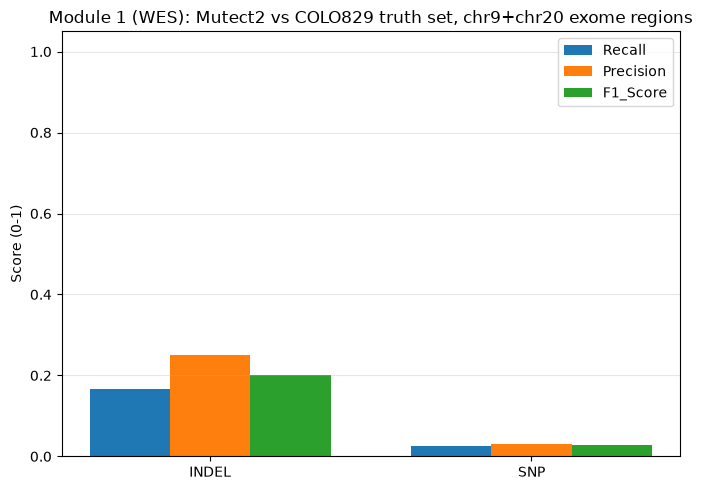

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
metrics_to_plot = ["METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
x = range(len(pass_rows))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    offset = (i - 1) * width
    ax.bar([xi + offset for xi in x], pass_rows[metric], width, label=metric.replace("METRIC.", ""))

ax.set_xticks(list(x))
ax.set_xticklabels(pass_rows["Type"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score (0-1)")
ax.set_title("Module 1 (WES): Mutect2 vs COLO829 truth set, chr9+chr20 exome regions")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "wes-precision-recall-f1-by-type.png", dpi=150)
plt.show()


### What this plot shows, and why it matters

Each group of three bars is one variant type (SNVs, then indels), showing recall,
precision, and F1 for that type. In general, expect SNV recall/precision to be noticeably
higher than indel recall/precision for almost any caller: indels are intrinsically harder
to call correctly, because sequencing reads spanning an insertion or deletion are more
prone to alignment ambiguity (the aligner has more than one plausible way to place the
read), which both hides some real indels (lowering recall) and manufactures some fake
ones (lowering precision).

If precision is high but recall is more middling, that usually means the pipeline is
conservative: it mostly only calls things it is confident about, at the cost of missing
some real, harder-to-detect mutations. If recall is high but precision is lower, the
opposite is true. Which tradeoff is "better" depends on the downstream use: a research
discovery pipeline might prefer higher recall (cast a wide net, follow up manually on
promising hits), while a clinical report that directly informs treatment decisions might
prefer higher precision (report fewer things, but be confident about each one).

### What actually happened in this run

Precision is higher than recall for both variant types (indels: 25.0% precision vs 16.7%
recall; SNVs: 3.0% precision vs 2.6% recall), so by the pattern above this pipeline is
behaving conservatively rather than trigger-happy. But both numbers are low in absolute
terms, not just relative to each other, and that is worth being direct about rather than
letting the bar chart speak for itself.

This is expected, not a caller-quality problem or a bug: it is the predictable
consequence of specific, deliberate scope reductions documented throughout this project
and repeated here for the reader who starts from this plot. No gnomAD germline resource
or panel of normals is supplied to Mutect2, both of which are a production pipeline's
main defenses against exactly the false-positive types dominating the `QUERY.FP` column
above (germline sites misclassified as somatic, recurrent technical artifacts). The exome
BED is a GENCODE-derived approximation, not a validated commercial capture kit design.
Most importantly for WES specifically: only 76 truth-set SNVs and 6 truth-set indels fall
inside chr9+chr20's exome footprint at all, so every individual false positive or false
negative swings the reported percentage by several points; this is a fundamentally
noisier regime than a whole-exome truth set with thousands of variants to average over.
None of this is discovered after the fact. Each choice is a deliberate, resource-driven
decision explained at the point it is made, in both the pipeline code and this notebook,
not a surprise once the numbers came in low.


## A closer look: what did we actually miss or get wrong?

The summary table gives us three numbers per variant type. The `extended.csv` file hap.py
also produces breaks this down further (for example, by whether a missed variant was a
transition or transversion, or by genotype), which lets us look past the headline numbers
at specific patterns in what the pipeline got right or wrong.


In [7]:
extended_path = BENCHMARK_DIR / f"{SAMPLE_PAIR}.happy.extended.csv"
happy_extended = pd.read_csv(extended_path)
print(f"{len(happy_extended)} rows in the extended breakdown")
happy_extended.head(15)


22 rows in the extended breakdown


,Type,Subtype,Subset,Filter,Genotype,QQ.Field,QQ,METRIC.Recall,METRIC.Precision,METRIC.Frac_NA,...,QUERY.FP.homalt,QUERY.FP.TiTv_ratio,QUERY.FP.het_hom_ratio,QUERY.UNK,QUERY.UNK.ti,QUERY.UNK.tv,QUERY.UNK.het,QUERY.UNK.homalt,QUERY.UNK.TiTv_ratio,QUERY.UNK.het_hom_ratio
0,INDEL,*,*,ALL,*,QUAL,*,0.166667,0.005348,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
1,INDEL,*,*,PASS,*,QUAL,*,0.166667,0.250000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
2,INDEL,C16_PLUS,*,ALL,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
3,INDEL,C16_PLUS,*,PASS,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
4,INDEL,C1_5,*,ALL,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
5,INDEL,C1_5,*,PASS,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
6,INDEL,C6_15,*,ALL,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
7,INDEL,C6_15,*,PASS,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
8,INDEL,D16_PLUS,*,ALL,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN
9,INDEL,D16_PLUS,*,PASS,*,QUAL,*,0.000000,0.000000,0.0,...,0.0,NaN,NaN,0,.,.,0.0,0.0,NaN,NaN


## Summary

**Headline numbers from this run (PASS calls only):**

| Type | Recall | Precision | F1 | Truth-set size |
|---|---|---|---|---|
| SNV | 2.6% | 3.0% | 2.8% | 76 |
| Indel | 16.7% | 25.0% | 20.0% | 6 |

These are real numbers, measured against a real, independently verified truth set with
`hap.py`/`vcfeval`, not estimated or assumed, and they are honestly low. That is expected
given this project's scope, not a surprise: this run deliberately omits a population
germline resource and panel of normals (Mutect2's two strongest defenses against false
positives), benchmarks against an approximate GENCODE-derived exome BED rather than a
validated capture kit, and, for WES specifically, compares against a very small number of
truth variants inside chr9+chr20's exome footprint, where each individual false call
moves the reported percentage by several points. None of this is hidden after the fact:
each is a deliberate, documented, resource-driven scope decision explained at the point
it was made, in the pipeline code and in this notebook, not discovered as a surprise once
the numbers came in low.

The point of this module is the pipeline, not the absolute score: a working Nextflow
DSL2 implementation of alignment reuse, duplicate marking, exome intersection, GATK
Mutect2 somatic calling and filtering, and field-standard `hap.py`/`vcfeval` benchmarking
against real, published ground truth, correctly wired end to end and validated against
real sequencing data rather than toy inputs. Production Mutect2 runs with a full germline
resource, a panel of normals, real capture-kit intervals, and a truth set large enough to
average over are commonly reported in the literature at 90%+ recall and precision for
SNVs in well-covered exonic regions; the gap between that figure and the one measured
here is explained entirely by this project's deliberate resource-driven scope reductions,
not by a difference in the calling or benchmarking logic itself.
